In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
TEST_YEAR = '2018'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(52992, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2018,1,21.76334,40.79806,0.313319,-0.080928,-0.300870,0.080928,0.297286,-0.090610,-0.287572,0.090610,0.022688,0.035234,0.018563,0.035234,7.833871,7.635806,8.970000,14.336452,25.177333,0.300323,0.506774,-0.205714,1.289355,10.158667,4.067097,4.071290,4.382143,7.812903,17.668000,-9.93,11.87,5.034564,3.981100,19.292321,52.512288,69.254835,13.625000,24.916667,43.713450,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.000000,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
1,1,EL52,EL524,εδεσσας,2018,1,21.76334,40.81603,0.326655,-0.099884,-0.351850,0.099884,0.321382,-0.108335,-0.355849,0.108335,0.015446,0.013693,0.028556,0.013693,7.890645,9.149355,9.122857,12.383548,25.672667,-0.466129,-0.312581,-0.571429,0.894516,8.288667,3.712258,4.418387,4.275714,6.639032,16.980667,-7.25,12.85,5.100148,3.339642,5.363738,25.496329,71.224402,13.500000,24.000000,53.333333,851.202358,37.0,-8.0,45.0,2.833333,18.666667,24.166667,2.833333,1240.0,287.0,35.0,67.877653,557.0,152.0,200.0,557.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
2,2,EL52,EL524,εδεσσας,2018,1,21.76334,40.83400,0.260793,-0.057039,-0.307720,0.057039,0.320305,-0.073719,-0.343888,0.073719,0.030420,0.023256,0.026564,0.023256,6.606129,8.024194,5.884286,9.710645,25.260000,-2.757097,-1.384194,-1.376429,0.788065,7.141333,1.924516,3.320000,2.253929,5.249355,16.200667,-9.21,12.93,5.100148,3.339642,5.363738,25.496329,71.224402,11.666667,24.500000,51.041667,871.866684,34.0,-14.0,48.0,1.166667,17.000000,21.666667,-0.166667,1240.0,287.0,35.0,67.877653,557.0,152.0,200.0,327.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
3,3,EL52,EL524,εδεσσας,2018,1,21.76334,40.85196,0.258720,0.065956,-0.281361,-0.065956,0.272690,-0.012280,-0.307161,0.012280,0.046103,0.084167,0.055325,0.084167,7.219032,5.940968,4.658571,8.687419,21.247333,-1.792581,-0.610645,-1.532143,0.000968,7.178000,2.713226,2.665161,1.563214,4.344194,14.212667,-8.17,12.01,5.100148,3.339642,5.363738,25.496329,71.224402,10.291667,24.083333,50.173611,805.508968,33.0,-15.0,48.0,0.666667,15.500000,19.000000,-0.666667,1240.0,287.0,35.0,67.877653,557.0,152.0,177.0,327.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2
4,4,EL52,EL524,εδεσσας,2018,1,21.78676,40.79806,-0.267616,0.530557,0.478454,-0.530557,-0.120742,0.325365,0.285808,-0.325365,0.220532,0.290329,0.299024,0.290329,8.387419,7.460968,8.149286,11.700323,21.028000,5.354516,2.722903,2.832857,2.744194,10.880000,6.87

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

4416

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

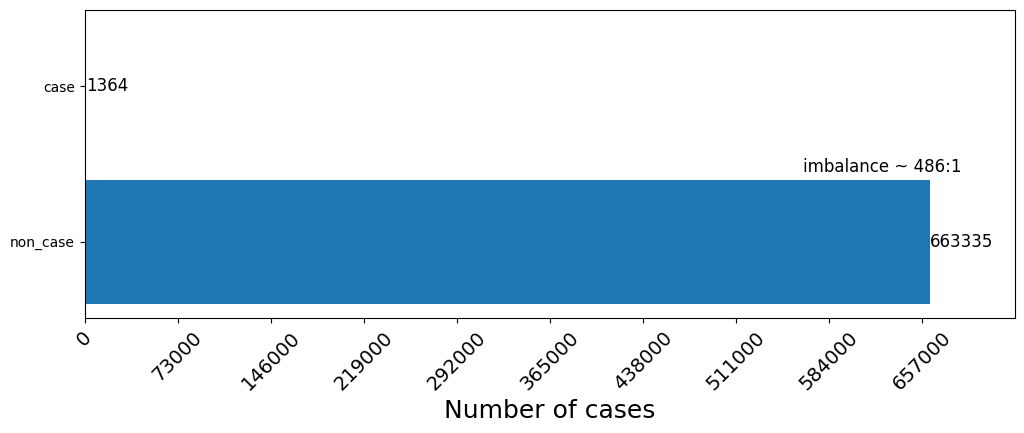

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

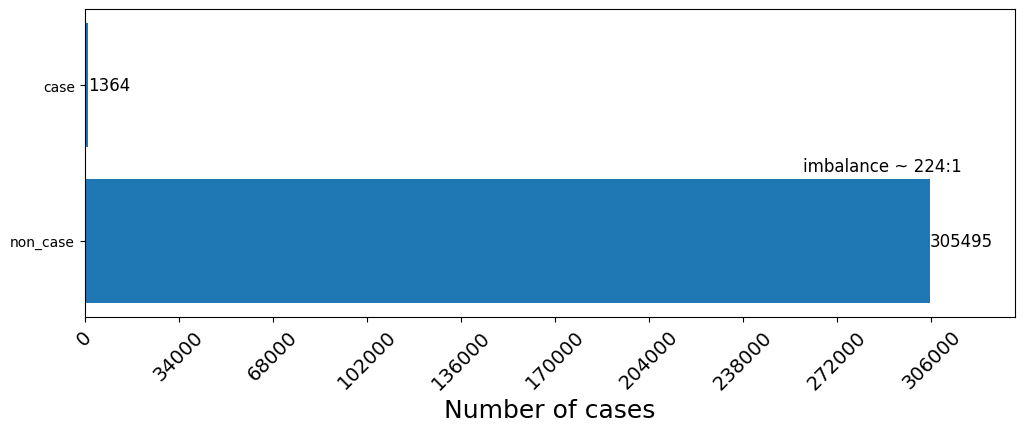

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

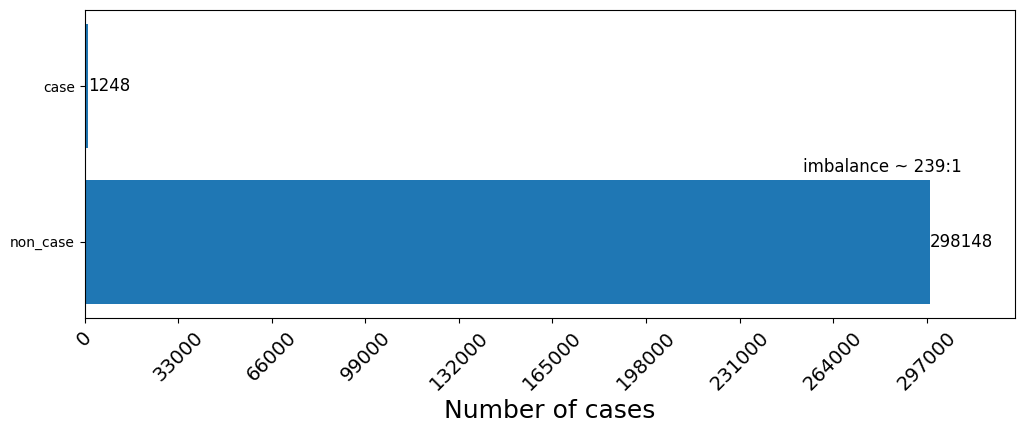

In [16]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

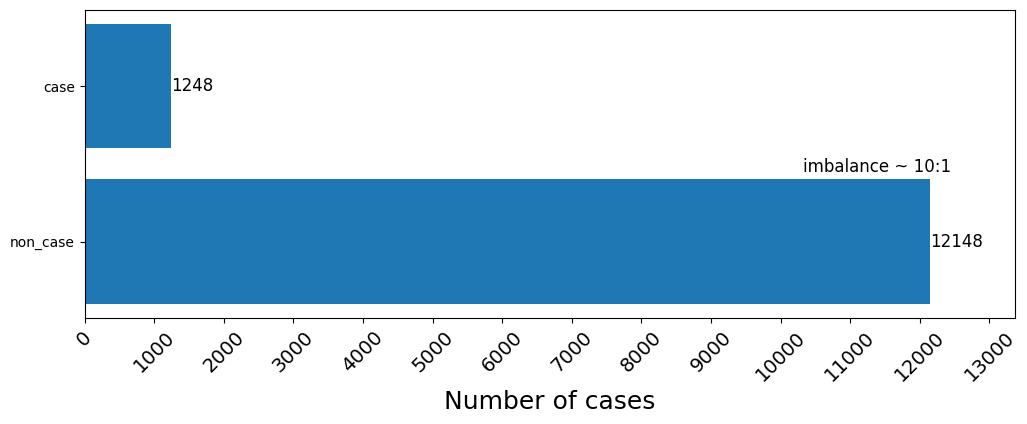

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(13262, 94)

In [19]:
data_train.cases.sum()

1248

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1045,262,1307,3.99%
1,2011,988,100,1088,9.88%
2,2012,1029,157,1186,6.55%
3,2013,1044,85,1129,12.28%
4,2014,981,15,996,65.40%
5,2015,1070,0,1070,inf%
6,2016,1055,0,1055,inf%
7,2017,992,42,1034,23.62%
8,2018,724,180,904,4.02%
9,2019,1068,218,1286,4.90%


In [21]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [22]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 9.73
Weight: 9.73


In [23]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [24]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2018,5,21.76334,40.79806,0.408381,-0.065172,-0.369258,0.065172,0.357442,-0.025376,-0.313345,0.025376,0.041805,0.049805,0.040286,0.049805,25.177333,7.635806,8.970000,14.336452,25.177333,10.158667,0.506774,-0.205714,1.289355,10.158667,17.668000,4.071290,4.382143,7.812903,17.668000,4.01,32.27,0.887055,8.326400,8.693120,26.611657,744.461411,13.625000,24.916667,43.713450,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.000000,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2018,5,21.76334,40.81603,0.377620,-0.084882,-0.389948,0.084882,0.353465,-0.114022,-0.373092,0.114022,0.017549,0.022948,0.007678,0.022948,25.672667,9.149355,9.122857,12.383548,25.672667,8.288667,-0.312581,-0.571429,0.894516,8.288667,16.980667,4.418387,4.275714,6.639032,16.980667,3.39,31.45,0.874664,5.082059,5.503383,26.239919,744.991251,13.500000,24.000000,53.333333,851.202358,37.0,-8.0,45.0,2.833333,18.666667,24.166667,2.833333,1240.0,287.0,35.0,67.877653,557.0,152.0,200.0,557.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2018,5,21.76334,40.83400,0.282404,-0.051030,-0.328026,0.051030,0.354735,-0.071360,-0.373576,0.071360,0.042130,0.051308,0.024023,0.051308,25.260000,8.024194,5.884286,9.710645,25.260000,7.141333,-1.384194,-1.376429,0.788065,7.141333,16.200667,3.320000,2.253929,5.249355,16.200667,1.61,28.53,0.874664,5.082059,5.503383,26.239919,744.991251,11.666667,24.500000,51.041667,871.866684,34.0,-14.0,48.0,1.166667,17.000000,21.666667,-0.166667,1240.0,287.0,35.0,67.877653,557.0,152.0,200.0,327.0,31,36,30,12,12,3,5,8,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2018,5,21.76334,40.85196,0.276591,-0.139402,-0.318478,0.139402,0.307219,-0.109267,-0.342870,0.109267,0.030083,0.040551,0.032276,0.040551,21.247333,5.940968,4.658571,8.687419,21.247333,7.178000,-0.610645,-1.532143,0.000968,7.178000,14.212667,2.665161,1.563214,4.344194,14.212667,2.69,26.31,0.874664,5.082059,5.503383,26.239919,744.991251,10.291667,24.083333,50.173611,805.508968,33.0,-15.0,48.0,0.666667,15.500000,19.000000,-0.666667,1240.0,287.0,35.0,67.877653,557.0,152.0,177.0,327.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1620.04,4297.0,2496.0,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2018,5,21.78676,40.79806,-0.151170,0.376394,0.382522,-0.376394,-0.015167,0.252759,0.204618,-0.252759,0.206844,0.165241,0.273495,0.165

### Results 2018 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

prediction_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
prediction_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1066,1066,EL52,EL524,πελλας,2018,5,22.41917,40.79806,0.068776
321,321,EL52,EL524,αλμωπιας,2018,5,22.06783,41.03163,0.048009
1413,1413,EL52,EL525,πυδνας κολινδρου,2018,5,22.55970,40.51060,0.042722
4031,4031,EL52,EL526,βισαλτιας,2018,5,23.70741,40.92383,0.036159
1176,1176,EL52,EL521,αλεξανδρειας,2018,5,22.46601,40.63636,0.035622


In [32]:
prediction_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2024,2024,EL52,EL522,παυλου μελα,2018,6,22.93447,40.67230,0.395209
1979,1979,EL52,EL522,αμπελοκηπων μενεμενης,2018,6,22.91104,40.65433,0.384439
1179,1179,EL52,EL521,αλεξανδρειας,2018,6,22.46601,40.69026,0.339545
1365,1365,EL52,EL521,αλεξανδρειας,2018,6,22.53628,40.65433,0.314733
1279,1279,EL52,EL525,κατερινης,2018,6,22.51286,40.25906,0.299225


In [33]:
prediction_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2966,2966,EL52,EL527,νεας προποντιδας,2018,7,23.33265,40.25906,0.917028
1936,1936,EL52,EL522,αμπελοκηπων μενεμενης,2018,7,22.88762,40.65433,0.909172
2319,2319,EL52,EL527,νεας προποντιδας,2018,7,23.07500,40.34890,0.907012
1356,1356,EL52,EL525,πυδνας κολινδρου,2018,7,22.53628,40.49263,0.899772
1461,1461,EL52,EL525,πυδνας κολινδρου,2018,7,22.58313,40.52856,0.888367


In [34]:
prediction_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2264,2264,EL52,EL527,νεας προποντιδας,2018,8,23.05158,40.34890,0.963373
2966,2966,EL52,EL527,νεας προποντιδας,2018,8,23.33265,40.25906,0.962102
2659,2659,EL52,EL527,νεας προποντιδας,2018,8,23.21554,40.31296,0.958416
1279,1279,EL52,EL525,κατερινης,2018,8,22.51286,40.25906,0.955552
2319,2319,EL52,EL527,νεας προποντιδας,2018,8,23.07500,40.34890,0.954054


In [35]:
prediction_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1217,1217,EL52,EL525,κατερινης,2018,9,22.48944,40.27703,0.951863
1356,1356,EL52,EL525,πυδνας κολινδρου,2018,9,22.53628,40.49263,0.950191
1280,1280,EL52,EL525,κατερινης,2018,9,22.51286,40.27703,0.946330
2264,2264,EL52,EL527,νεας προποντιδας,2018,9,23.05158,40.34890,0.946170
2717,2717,EL52,EL527,νεας προποντιδας,2018,9,23.23896,40.31296,0.942373


In [36]:
prediction_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1279,1279,EL52,EL525,κατερινης,2018,10,22.51286,40.25906,0.801885
2717,2717,EL52,EL527,νεας προποντιδας,2018,10,23.23896,40.31296,0.768884
2264,2264,EL52,EL527,νεας προποντιδας,2018,10,23.05158,40.34890,0.733811
1452,1452,EL52,EL525,κατερινης,2018,10,22.58313,40.33093,0.669904
1355,1355,EL52,EL525,πυδνας κολινδρου,2018,10,22.53628,40.47466,0.652028


In [37]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\limnes\lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [38]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [39]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [40]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [41]:
greece_lau1.head()

,NAME,geometry
0,Δέλτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
1,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
2,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
3,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
4,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [42]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256...",0
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087...",1
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40...",2
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179...",3
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039...",4


In [43]:
prediction_may = pd.merge(prediction_may, region_grid, on='cell_number', how='left')
prediction_may = gpd.GeoDataFrame(prediction_may, geometry='geometry')
prediction_may['x'] = prediction_may['x'].round(4)
prediction_may['y'] = prediction_may['y'].round(4)
prediction_may.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_may['risk_score'] = prediction_may['risk_score'].round(6)

prediction_jun = pd.merge(prediction_jun, region_grid, on='cell_number', how='left')
prediction_jun = gpd.GeoDataFrame(prediction_jun, geometry='geometry')
prediction_jun['x'] = prediction_jun['x'].round(4)
prediction_jun['y'] = prediction_jun['y'].round(4)
prediction_jun.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_jun['risk_score'] = prediction_jun['risk_score'].round(6)

prediction_jul = pd.merge(prediction_jul, region_grid, on='cell_number', how='left')
prediction_jul = gpd.GeoDataFrame(prediction_jul, geometry='geometry')
prediction_jul['x'] = prediction_jul['x'].round(4)
prediction_jul['y'] = prediction_jul['y'].round(4)
prediction_jul.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_jul['risk_score'] = prediction_jul['risk_score'].round(6)

prediction_aug = pd.merge(prediction_aug, region_grid, on='cell_number', how='left')
prediction_aug = gpd.GeoDataFrame(prediction_aug, geometry='geometry')
prediction_aug['x'] = prediction_aug['x'].round(4)
prediction_aug['y'] = prediction_aug['y'].round(4)
prediction_aug.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_aug['risk_score'] = prediction_aug['risk_score'].round(6)

prediction_sep = pd.merge(prediction_sep, region_grid, on='cell_number', how='left')
prediction_sep = gpd.GeoDataFrame(prediction_sep, geometry='geometry')
prediction_sep['x'] = prediction_sep['x'].round(4)
prediction_sep['y'] = prediction_sep['y'].round(4)
prediction_sep.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_sep['risk_score'] = prediction_sep['risk_score'].round(6)

prediction_oct = pd.merge(prediction_oct, region_grid, on='cell_number', how='left')
prediction_oct = gpd.GeoDataFrame(prediction_oct, geometry='geometry')
prediction_oct['x'] = prediction_oct['x'].round(4)
prediction_oct['y'] = prediction_oct['y'].round(4)
prediction_oct.rename(columns={'score': 'risk_score'}, inplace=True)
prediction_oct['risk_score'] = prediction_oct['risk_score'].round(6)

In [44]:
wnv_cases_may = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_jun = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_jul = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
wnv_cases_aug = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
wnv_cases_sep = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
wnv_cases_oct = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]

In [45]:
type(prediction_may)

geopandas.geodataframe.GeoDataFrame

In [46]:
# results_may.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_aug.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_sep.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [47]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

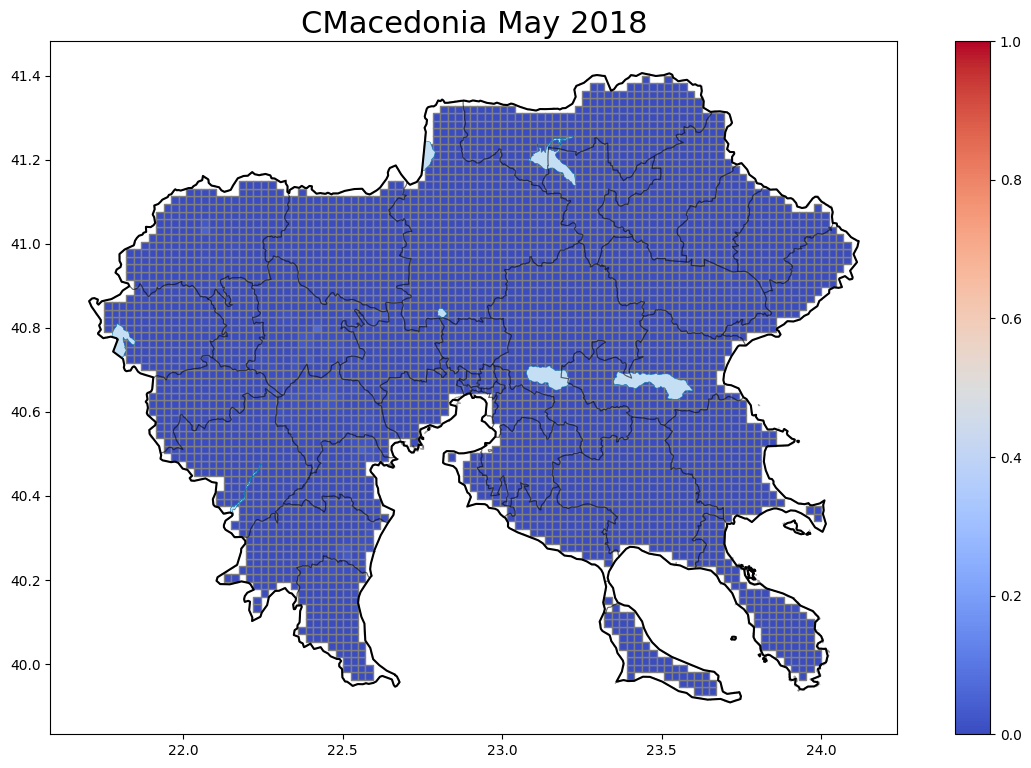

In [48]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_may.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_may.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

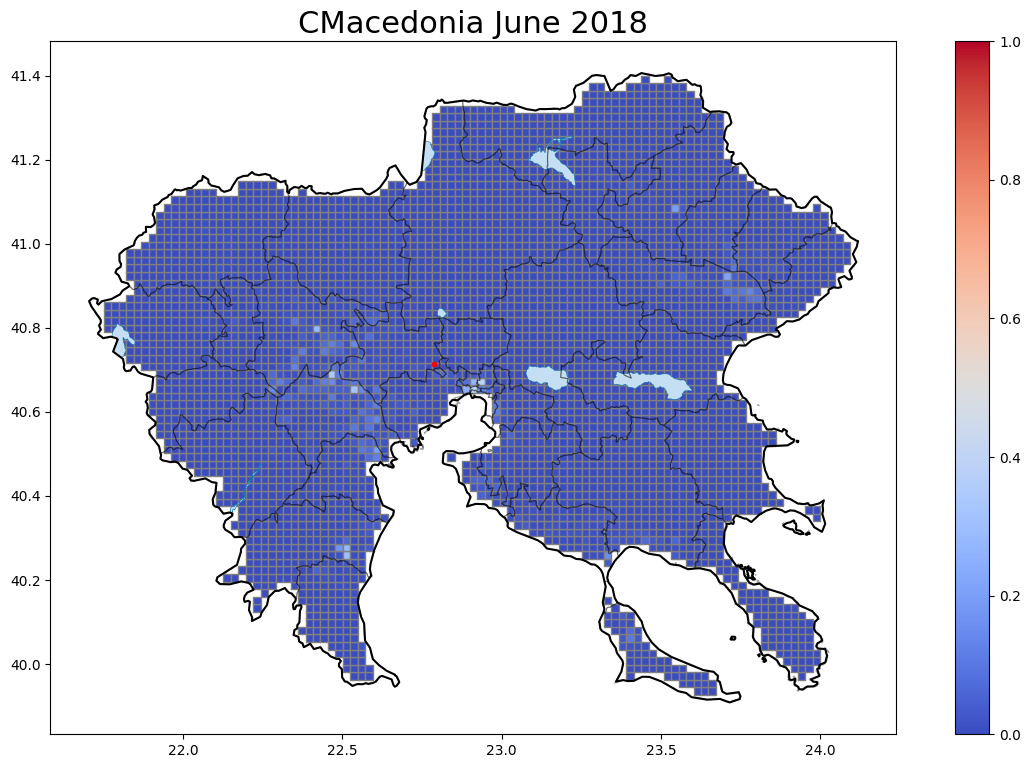

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_jun.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_jun.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

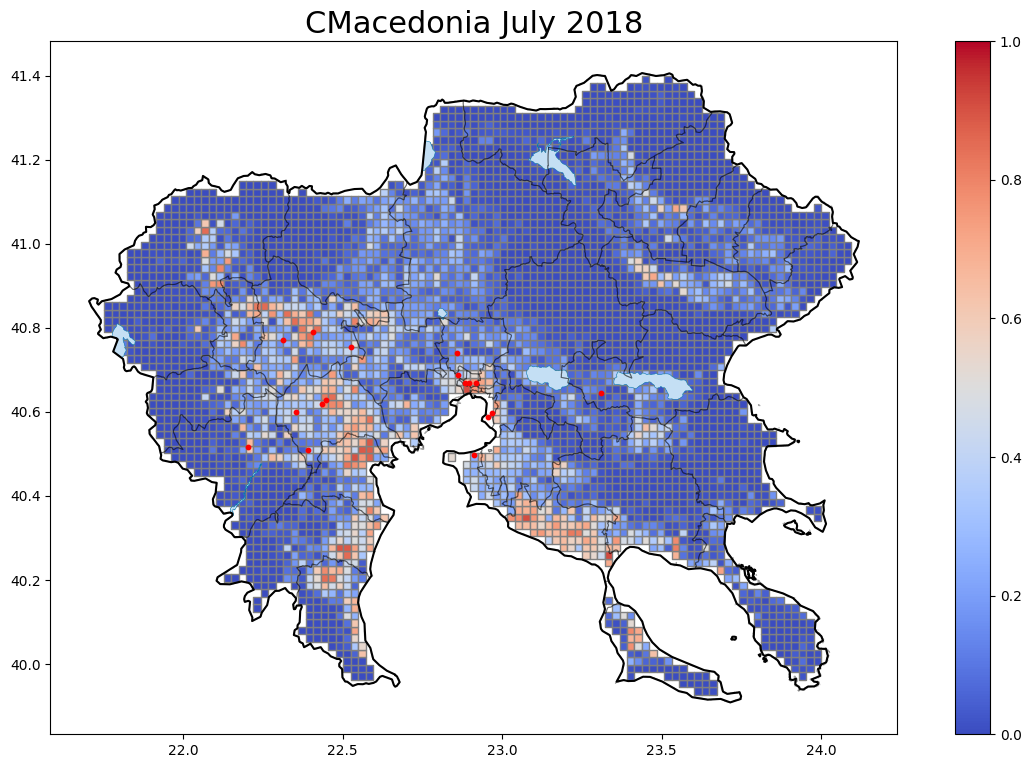

In [50]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_jul.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_jul.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

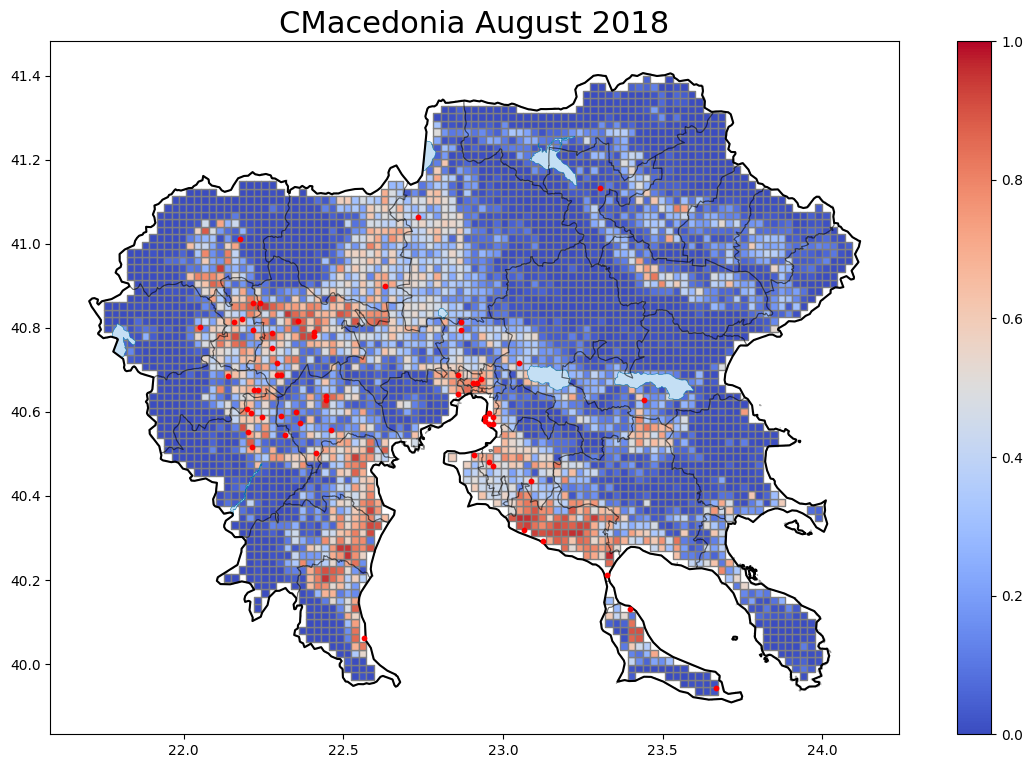

In [51]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_aug.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_aug.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

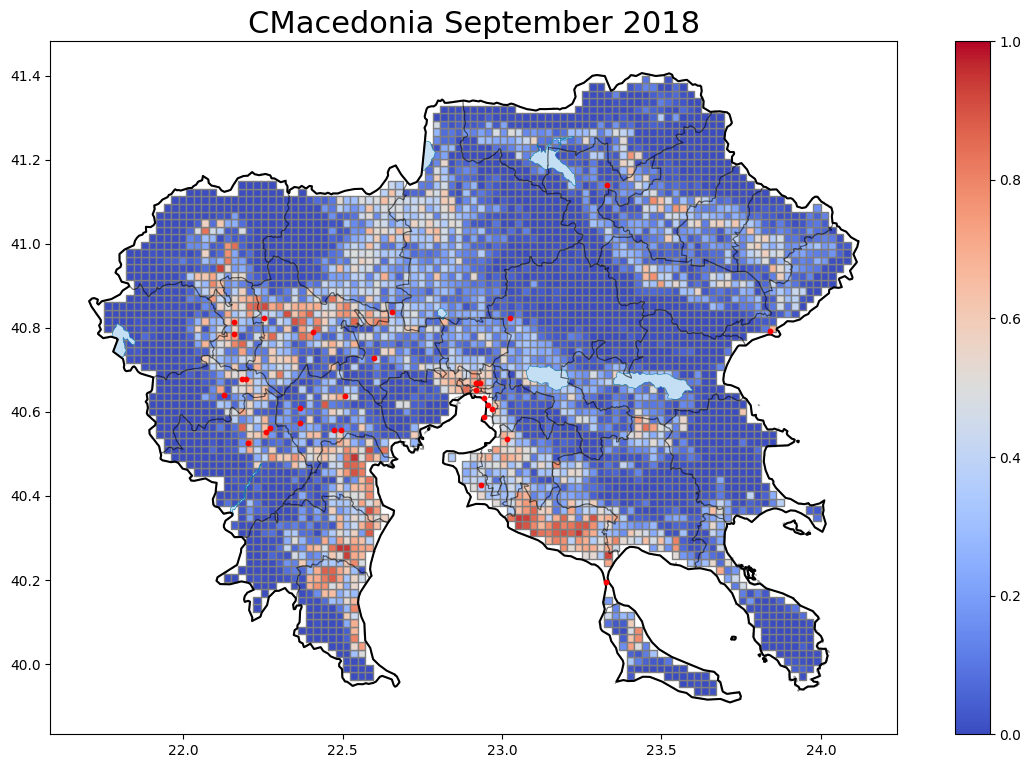

In [52]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_sep.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_sep.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

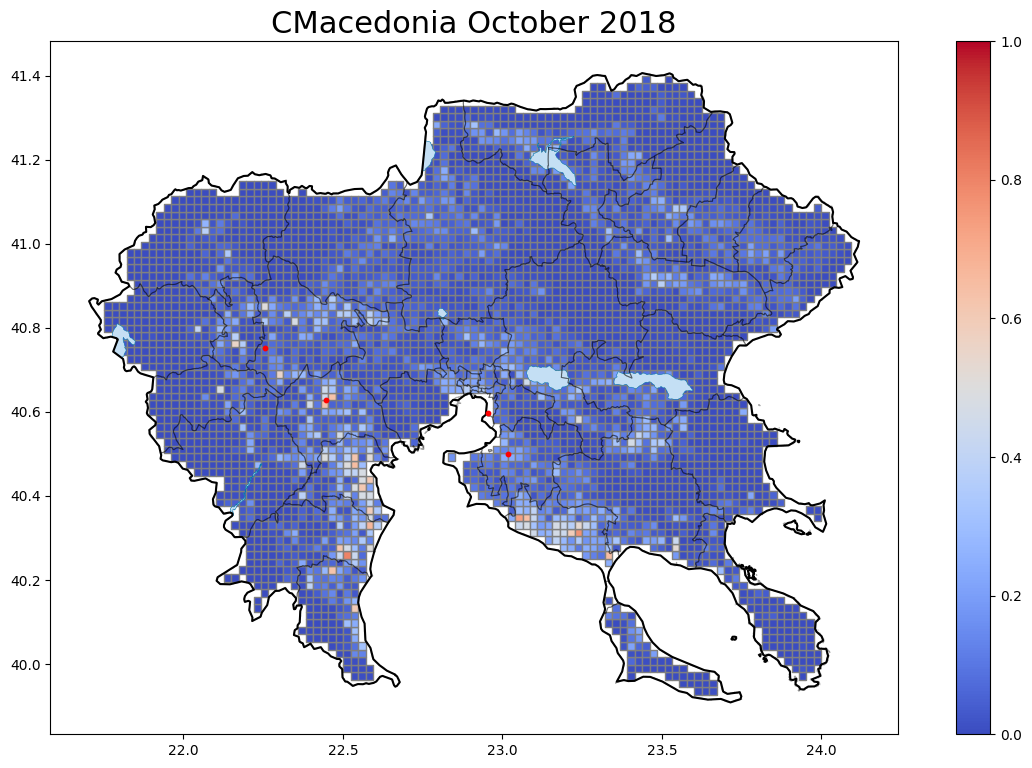

In [53]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_oct.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
prediction_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_oct.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(prediction_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [54]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_nuts3_gdf, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8, line_color_f4='#3b3b3b', fig_title = '[EL52]Central Macedonia - August 2018',
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=670, fig_width=1000, size_f5=6.5)

# fig.show()


# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [55]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.9, line_width_f1 = 0.4, 
#                                  fig_title = 'WNV Risk | Central Macedonia - August 2018', color_f5='#222120',
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5, opacity_f5=1)

# fig.show() 


# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [56]:
import geopandas as gpd

def polygons_within_radius(points_gdf, polygons_gdf, radius_meters):
    """
    For each point, find indexes of polygons whose *centroid* lies
    within R meters of the point. Works even if points_gdf is empty.
    """

    # Handle empty points_gdf early
    if len(points_gdf) == 0:
        out = points_gdf.copy()
        out["matching_polygons"] = []  # empty column
        return out

    # 1. Save CRS
    orig_crs = points_gdf.crs

    # 2. Determine metric CRS safely
    try:
        metric_crs = points_gdf.estimate_utm_crs()
    except Exception:
        # fallback to polygons CRS if points are missing or invalid
        metric_crs = polygons_gdf.estimate_utm_crs()

    # 3. Reproject
    pts = points_gdf.to_crs(metric_crs)
    polys = polygons_gdf.to_crs(metric_crs)

    # 4. Precompute centroids
    polys["centroid_geom"] = polys.geometry.centroid

    # 5. Build spatial index
    sindex = polys.sindex

    results = []

    # 6. Main loop
    for pt in pts.geometry:
        circle = pt.buffer(radius_meters)

        # candidate search
        cand_idx = list(sindex.intersection(circle.bounds))

        if not cand_idx:
            results.append([])
            continue

        # centroid-within test
        centroids = polys.loc[cand_idx, "centroid_geom"]
        hits = centroids.within(circle)

        match_idx = list(centroids[hits].index)
        results.append(match_idx)

    # 7. Output with original CRS
    out = points_gdf.copy()
    out["matching_polygons"] = results

    return out


In [82]:
def plot_point_matches(points_gdf, polygons_gdf, lau1_gdf, nuts2_gdf, lakes_gdf,
                       point_indexes, radius_meters):
    """
    Plot polygons matched by centroid-based logic.
    Does NOT recompute matches.
    Fully safe: works even if points_gdf or point_indexes is empty.
    """

    # ----------------------------------------------
    # 0. Normalize and guard against emptiness
    # ----------------------------------------------

    # Normalize point_indexes into a list
    if isinstance(point_indexes, int):
        point_indexes = [point_indexes]
    else:
        point_indexes = list(point_indexes)

    # If no points to plot → just plot polygons and exit
    if len(points_gdf) == 0 or len(point_indexes) == 0:
        print("Nothing to plot: points_gdf is empty or point_indexes is empty.")
        fig, ax = plt.subplots(figsize=(15, 9))
        polygons_gdf.plot(ax=ax, column='risk_score', cmap=plt.cm.coolwarm, edgecolor='grey', alpha=0.5, legend=True, vmin=0, vmax=1)
        nuts2_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
        lau1_gdf.plot(ax=ax, color=nuts_face_color, edgecolor='black', linewidth=0.8, alpha=0.35)
        lakes_gdf.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth=0.4)
        plt.title(f'{NUTS2} {month_dict.get(polygons_gdf.month.iloc[0])} {TEST_YEAR} Evaluation', size = 22)
        plt.show()
        return  # exit early — nothing else to plot

    # Make sure indexes are within range
    point_indexes = [i for i in point_indexes if i < len(points_gdf)]
    if len(point_indexes) == 0:
        print("No valid point indexes to plot.")
        return

    # ----------------------------------------------
    # 1. CRS detection (safe)
    # ----------------------------------------------

    try:
        metric_crs = points_gdf.estimate_utm_crs()
    except Exception:
        metric_crs = polygons_gdf.estimate_utm_crs()

    # ----------------------------------------------
    # 2. Reprojection
    # ----------------------------------------------

    pts_m = points_gdf.to_crs(metric_crs)
    polys_m = polygons_gdf.to_crs(metric_crs)
    lakes_m = lakes_gdf.to_crs(metric_crs)
    lau1_m = lau1_gdf.to_crs(metric_crs)
    nuts2_m = nuts2_gdf.to_crs(metric_crs)

    # ----------------------------------------------
    # 3. Create buffers for the selected points
    # ----------------------------------------------

    selected_points = pts_m.geometry.iloc[point_indexes]
    buffers = selected_points.buffer(radius_meters)

    # ----------------------------------------------
    # 4. USE PRECOMPUTED MATCHES (no recomputation)
    # ----------------------------------------------

    matched_ids = set()
    for idx in point_indexes:
        if "matching_polygons" not in points_gdf.columns:
            raise ValueError("points_gdf is missing the column 'matching_polygons'.")
        matched_ids.update(points_gdf["matching_polygons"].iloc[idx])

    matched_polygons = polys_m.loc[list(matched_ids)] if matched_ids else polys_m.iloc[[]]

    # ----------------------------------------------
    # 5. Plot
    # ----------------------------------------------

    fig, ax = plt.subplots(figsize=(15, 9))

    polys_m.plot(ax=ax, column='risk_score', cmap=plt.cm.coolwarm, edgecolor='grey', alpha = 0.30, legend=True, vmin=0, vmax=1)

    if len(matched_polygons) > 0:
        matched_polygons.plot(ax=ax, column='risk_score', cmap=plt.cm.coolwarm, edgecolor='grey', alpha = 1, vmin=0, vmax=1)

    gpd.GeoSeries(selected_points).plot(ax=ax, color='red', markersize=5)
    #gpd.GeoSeries(buffers).plot(ax=ax, facecolor="none", edgecolor='black', linewidth=1.2, alpha=0.7)

    lakes_m.plot(ax=ax, color='#c4dff4', edgecolor='#0978ab', linewidth=0.4)
    nuts2_m.plot(ax=ax, color='none', edgecolor='black', linewidth=1.5)
    lau1_m.plot(ax=ax, color=nuts_face_color, edgecolor='black', linewidth=0.8, alpha=0.35)

    ax.set_title(f'{NUTS2} {month_dict.get(polygons_gdf.month.iloc[0])} {TEST_YEAR} Evaluation', size = 22)
    plt.show()


In [58]:
def compute_risk_stats(result_gdf, prediction_gdf):
    """
    Computes for each point:
      - mean_risk
      - std_risk
      - distance-weighted risk (w_risk)

    Uses centroid-based distances.
    """

    # Precompute centroids once
    prediction_gdf["centroid"] = prediction_gdf.geometry.centroid

    mean_list = []
    std_list = []
    weighted_list = []

    # Loop once over result rows
    for i, row in result_gdf.iterrows():
        matches = row["matching_polygons"]

        if len(matches) == 0:
            mean_list.append(np.nan)
            std_list.append(np.nan)
            weighted_list.append(np.nan)
            continue

        # Risk scores
        scores = prediction_gdf.loc[matches, "risk_score"]
        mean_list.append(round(scores.mean(), 4))
        std_list.append(round(scores.std(), 4))

        # Centroid distances
        centroids = prediction_gdf.loc[matches, "centroid"]
        d = centroids.distance(row.geometry).replace(0, 1e-6)

        # Weights: inverse distance
        w = 1 / d
        w_risk = np.sum(w * scores) / np.sum(w)

        weighted_list.append(round(w_risk, 4))

    # Assign all new columns
    result_gdf["mean_risk"] = mean_list
    result_gdf["std_risk"] = std_list
    result_gdf["w_risk"] = weighted_list

    return result_gdf

In [59]:
R = 2500  # meters

In [104]:
wnv_cases_may.cases.sum()

0

In [60]:
result_may = polygons_within_radius(wnv_cases_may, prediction_may, R)
result_jun = polygons_within_radius(wnv_cases_jun, prediction_jun, R)
result_jul = polygons_within_radius(wnv_cases_jul, prediction_jul, R)
result_aug = polygons_within_radius(wnv_cases_aug, prediction_aug, R)
result_sep = polygons_within_radius(wnv_cases_sep, prediction_sep, R)
result_oct = polygons_within_radius(wnv_cases_oct, prediction_oct, R)

In [61]:
result_may = compute_risk_stats(result_may, prediction_may)
result_jun = compute_risk_stats(result_jun, prediction_jun)
result_jul = compute_risk_stats(result_jul, prediction_jul)
result_aug = compute_risk_stats(result_aug, prediction_aug)
result_sep = compute_risk_stats(result_sep, prediction_sep)
result_oct = compute_risk_stats(result_oct, prediction_oct)

In [106]:
print(f"May - Total Cases: {wnv_cases_may.cases.sum()} | Mean Risk > 0.4 : {(result_may['w_risk'] > 0.4).mean() * 100:.2f}%")
print(f"June - Total Cases: {wnv_cases_jun.cases.sum()} | Mean Risk > 0.4 : {(result_jun['w_risk'] > 0.4).mean() * 100:.2f}%")
print(f"July - Total Cases: {wnv_cases_jul.cases.sum()} | Mean Risk > 0.4 : {(result_jul['w_risk'] > 0.4).mean() * 100:.2f}%")
print(f"August - Total Cases: {wnv_cases_aug.cases.sum()} | Mean Risk > 0.4 : {(result_aug['w_risk'] > 0.4).mean() * 100:.2f}%")
print(f"September - Total Cases: {wnv_cases_sep.cases.sum()} | Mean Risk > 0.4 : {(result_sep['w_risk'] > 0.4).mean() * 100:.2f}%")
print(f"October - Total Cases: {wnv_cases_oct.cases.sum()} | Mean Risk > 0.4 : {(result_oct['w_risk'] > 0.4).mean() * 100:.2f}%")

May - Total Cases: 0 | Mean Risk > 0.4 : nan%
June - Total Cases: 1 | Mean Risk > 0.4 : 0.00%
July - Total Cases: 19 | Mean Risk > 0.4 : 58.82%
August - Total Cases: 62 | Mean Risk > 0.4 : 69.49%
September - Total Cases: 31 | Mean Risk > 0.4 : 56.67%
October - Total Cases: 4 | Mean Risk > 0.4 : 25.00%


In [63]:
print(round(np.nanmean([(result_may['w_risk'] > 0.4).mean(),
                        (result_jun['w_risk'] > 0.4).mean(), 
                        (result_jul['w_risk'] > 0.4).mean(),
                        (result_aug['w_risk'] > 0.4).mean(),
                        (result_sep['w_risk'] > 0.4).mean(),
                        (result_oct['w_risk'] > 0.4).mean()]),4))

0.42


In [ ]:
# temp_df = pd.DataFrame(columns=['range', 'value'])

# for R in range(500, 8100, 100):
#     result_may = polygons_within_radius(wnv_cases_may, prediction_may, R)
#     result_jun = polygons_within_radius(wnv_cases_jun, prediction_jun, R)
#     result_jul = polygons_within_radius(wnv_cases_jul, prediction_jul, R)
#     result_aug = polygons_within_radius(wnv_cases_aug, prediction_aug, R)
#     result_sep = polygons_within_radius(wnv_cases_sep, prediction_sep, R)
#     result_oct = polygons_within_radius(wnv_cases_oct, prediction_oct, R)

#     result_may = compute_risk_stats(result_may, prediction_may)
#     result_jun = compute_risk_stats(result_jun, prediction_jun)
#     result_jul = compute_risk_stats(result_jul, prediction_jul)
#     result_aug = compute_risk_stats(result_aug, prediction_aug)
#     result_sep = compute_risk_stats(result_sep, prediction_sep)
#     result_oct = compute_risk_stats(result_oct, prediction_oct)

#     perc = round(np.nanmean([(result_may['w_risk'] > 0.4).mean(),
#                              (result_jun['w_risk'] > 0.4).mean(), 
#                              (result_jul['w_risk'] > 0.4).mean(),
#                              (result_aug['w_risk'] > 0.4).mean(),
#                              (result_sep['w_risk'] > 0.4).mean(),
#                              (result_oct['w_risk'] > 0.4).mean()]),4)
    
#     temp_df = pd.concat([temp_df, pd.DataFrame({'range':[R], 'value':[perc]})],
#                         ignore_index=True)

In [ ]:
# temp_df

,range,value
0,500,0.0488
1,600,0.0774
2,700,0.1194
3,800,0.1732
4,900,0.2185
...,...,...
71,7600,0.3383
72,7700,0.3383
73,7800,0.3383
74,7900,0.3383


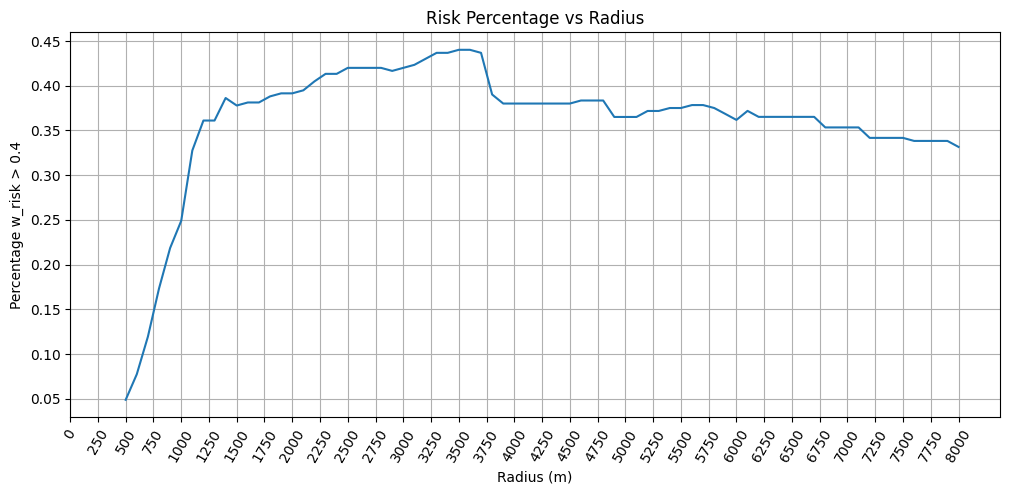

In [ ]:
# plt.figure(figsize=(12,5))
# plt.plot(temp_df["range"], temp_df["value"])
# plt.xticks(range(0, 8250, 250), rotation=60)
# plt.xlabel("Radius (m)")
# plt.ylabel("Percentage w_risk > 0.4")
# plt.title("Risk Percentage vs Radius")
# plt.grid(True)

Nothing to plot: points_gdf is empty or point_indexes is empty.


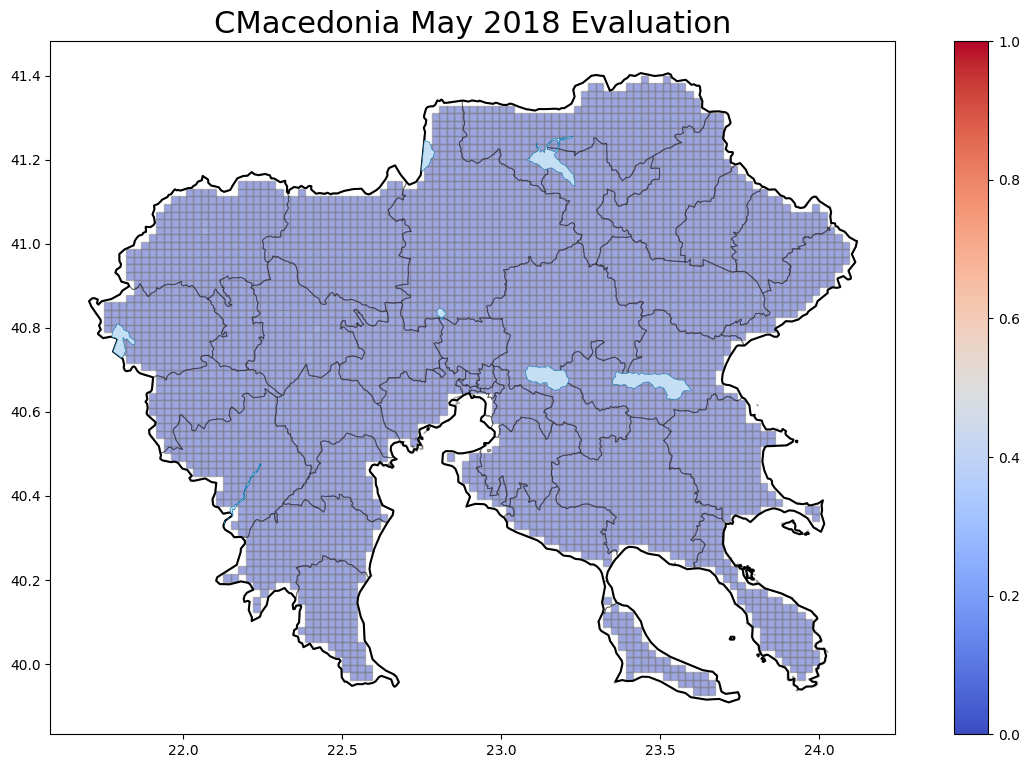

In [83]:
plot_point_matches(result_may, prediction_may, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_may)), radius_meters=R)

In [84]:
result_may[['cell_number', 'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk','w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk


In [85]:
print(f"{(result_may['w_risk'] > 0.4).mean() * 100:.2f}%")

nan%


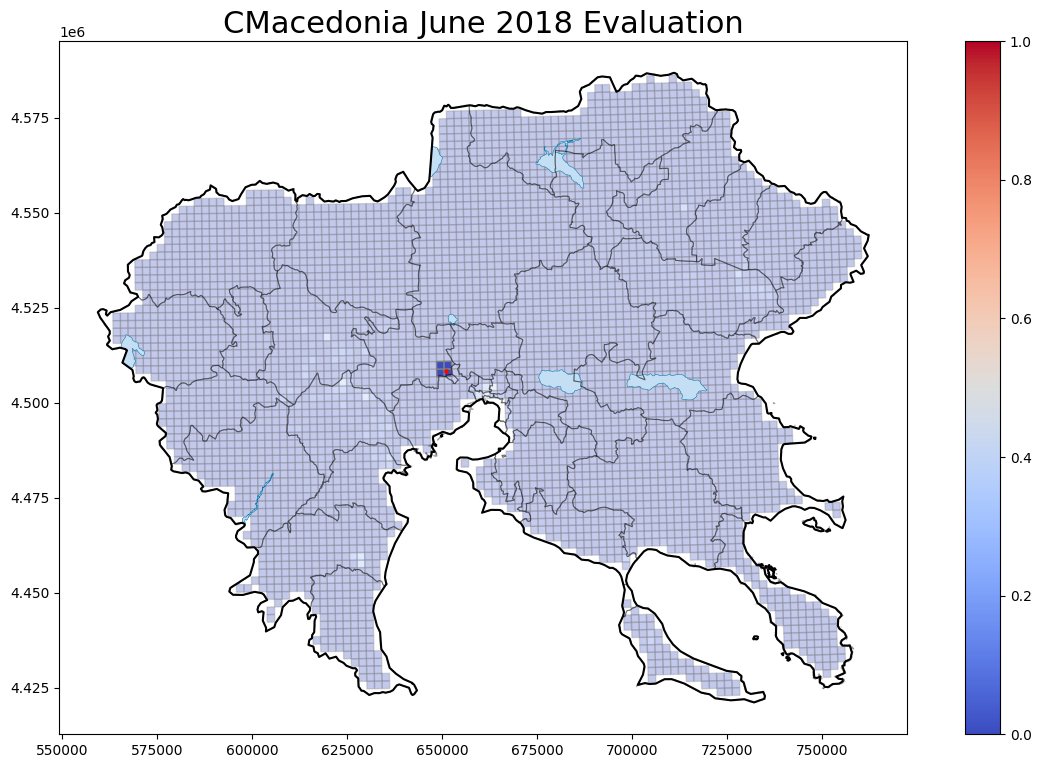

In [86]:
plot_point_matches(result_jun, prediction_jun, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_jun)), radius_meters=R)

In [87]:
result_jun[['cell_number', 'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk', 'w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk
485,DN294,2018,6,κεντρικης μακεδονιας,1,0.0021,0.0023,0.005


In [88]:
print(f"{(result_jun['w_risk'] > 0.4).mean() * 100:.2f}%")

0.00%


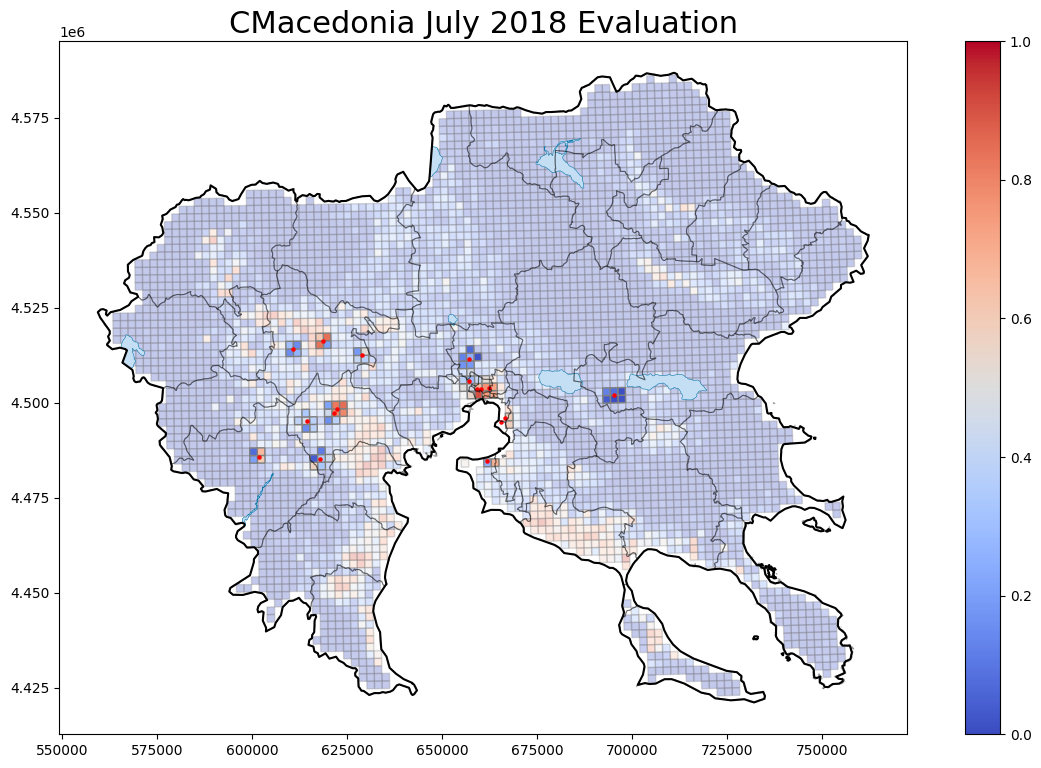

In [89]:
plot_point_matches(result_jul, prediction_jul, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_jul)), radius_meters=R)

In [91]:
result_jul[['cell_number', 'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk', 'w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk
580,DW265,2018,7,κεντρικης μακεδονιας,1,0.8110,0.0270,0.8084
534,DS305,2018,7,κεντρικης μακεδονιας,2,0.6908,0.0987,0.7322
528,DS303,2018,7,κεντρικης μακεδονιας,1,0.7012,0.1753,0.6890
591,DX264,2018,7,κεντρικης μακεδονιας,1,0.4677,0.2813,0.6758
526,DS302,2018,7,κεντρικης μακεδονιας,2,0.6291,0.1833,0.6500
395,DE262,2018,7,κεντρικης μακεδονιας,1,0.6229,0.2987,0.6216
652,EA309,2018,7,κεντρικης μακεδονιας,1,0.5908,0.0087,0.5924
662,EB308,2018,7,κεντρικης μακεδονιας,1,0.5847,NaN,0.5847
716,EI244,2018,7,κεντρικης μακεδονιας,1,0.3844,0.2846,0.5330
618,DZ257,2018,7,κεντρικης μακεδονιας,1,0.3560,0.1065,0.4684


In [92]:
print(f"{(result_jul['w_risk'] > 0.4).mean() * 100:.2f}%")

58.82%


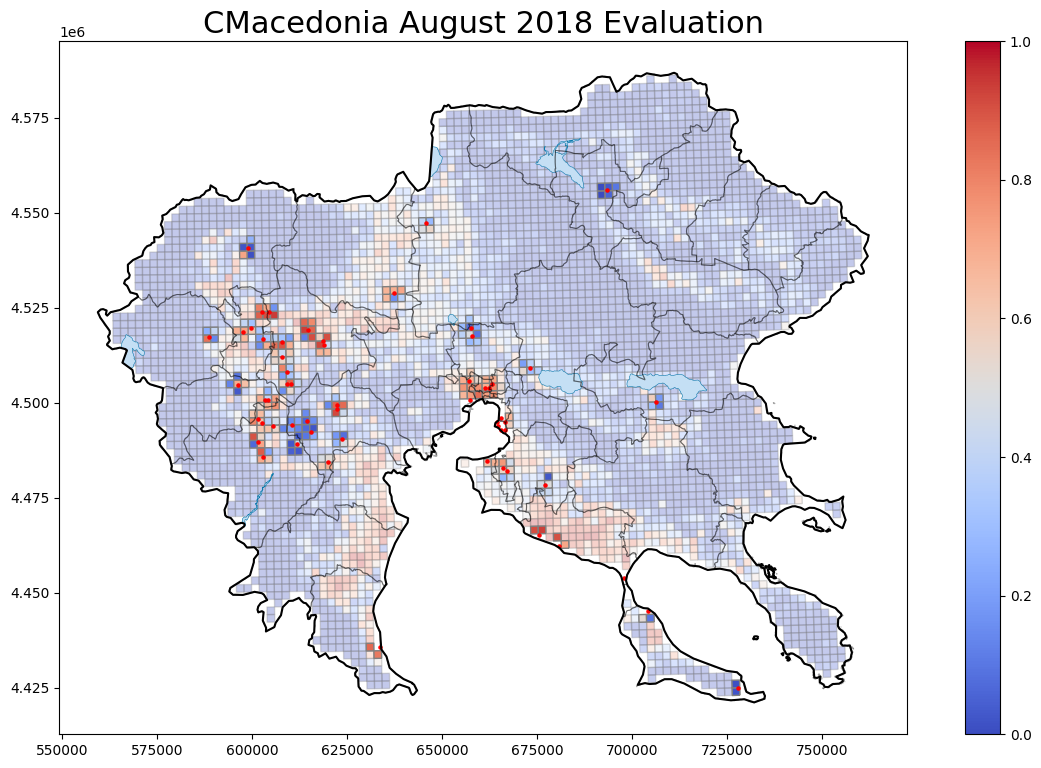

In [93]:
plot_point_matches(result_aug, prediction_aug, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_aug)), radius_meters=R)

In [94]:
result_aug[['cell_number', 'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk', 'w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk
761,FF317,2018,8,κεντρικης μακεδονιας,1,0.9191,0.0170,0.9213
567,DV265,2018,8,κεντρικης μακεδονιας,1,0.6245,0.3561,0.8681
502,DP253,2018,8,κεντρικης μακεδονιας,1,0.5425,0.2015,0.8601
332,CW246,2018,8,κεντρικης μακεδονιας,1,0.8278,0.0867,0.8478
790,GH274,2018,8,κεντρικης μακεδονιας,1,0.8401,0.0225,0.8359
581,DW265,2018,8,κεντρικης μακεδονιας,2,0.7701,0.2195,0.8316
768,FI322,2018,8,κεντρικης μακεδονιας,1,0.8087,0.1368,0.8026
361,DB258,2018,8,κεντρικης μακεδονιας,1,0.7467,0.3096,0.7997
334,CW248,2018,8,κεντρικης μακεδονιας,1,0.6821,0.3572,0.7657
521,DR306,2018,8,κεντρικης μακεδονιας,1,0.6864,0.0863,0.7515


In [95]:
print(f"{(result_aug['w_risk'] > 0.4).mean() * 100:.2f}%")

69.49%


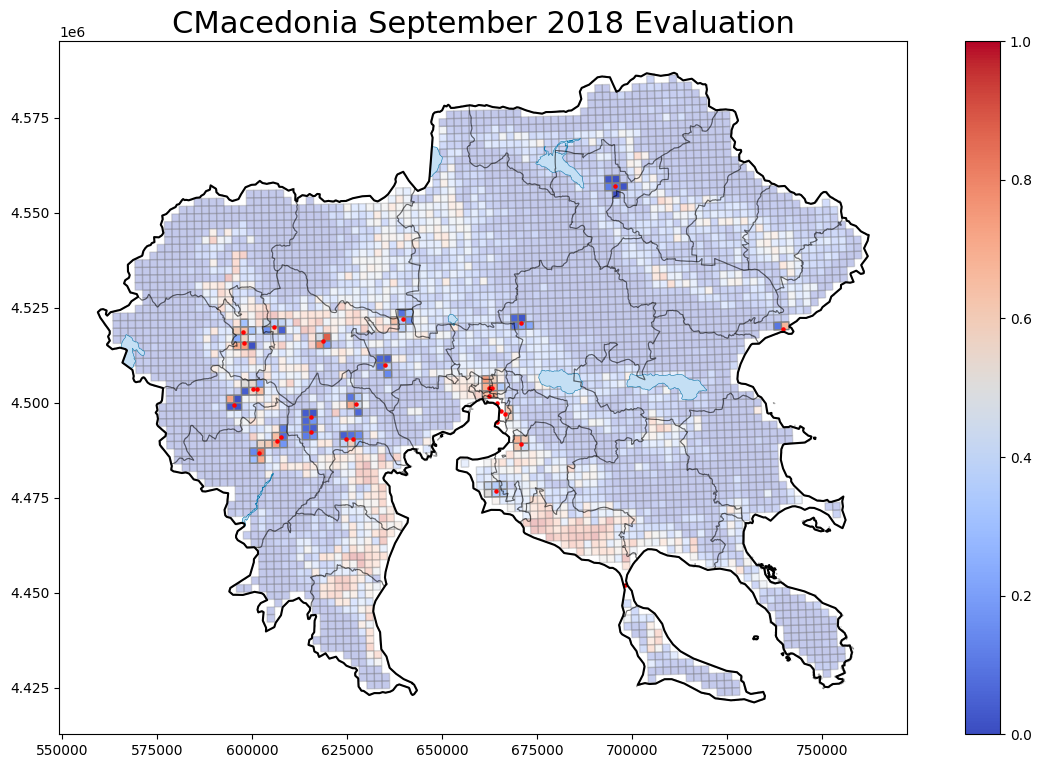

In [96]:
plot_point_matches(result_sep, prediction_sep, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_sep)), radius_meters=R)

In [97]:
result_sep[['cell_number', 'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk', 'w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk
706,EH244,2018,9,κεντρικης μακεδονιας,1,0.5090,0.2816,0.7348
537,DS306,2018,9,κεντρικης μακεδονιας,1,0.6114,0.1291,0.7071
536,DS305,2018,9,κεντρικης μακεδονιας,1,0.6942,0.0358,0.6927
589,DW307,2018,9,κεντρικης μακεδονιας,1,0.6884,NaN,0.6884
387,DE241,2018,9,κεντρικης μακεδονιας,1,0.4467,0.3118,0.6586
561,DU305,2018,9,κεντρικης μακεδονιας,1,0.6747,0.0293,0.6563
358,DB241,2018,9,κεντρικης μακεδονιας,1,0.4499,0.1727,0.6500
689,EE249,2018,9,κεντρικης μακεδονιας,1,0.4497,0.3009,0.6181
609,DY308,2018,9,κεντρικης μακεδονιας,1,0.5905,NaN,0.5905
629,DZ309,2018,9,κεντρικης μακεδονιας,1,0.5874,0.0043,0.5870


In [98]:
print(f"{(result_sep['w_risk'] > 0.4).mean() * 100:.2f}%")

56.67%


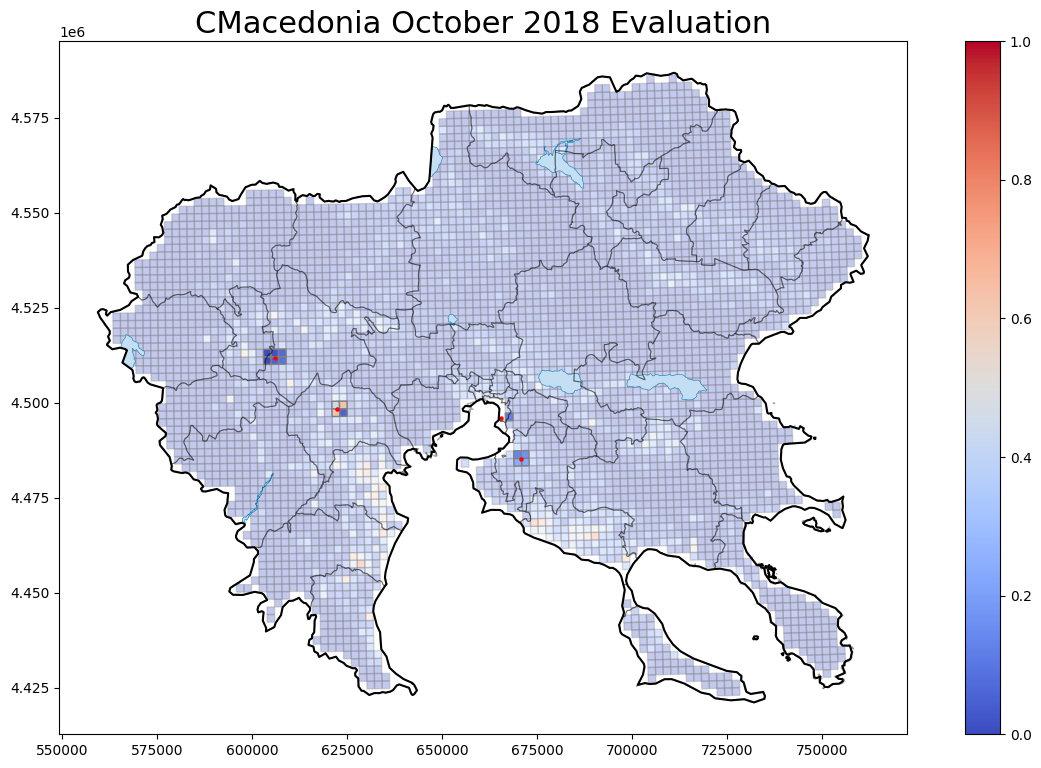

In [99]:
plot_point_matches(result_oct, prediction_oct, greece_lau1, greece_nuts2_gdf, greece_lakes, point_indexes=range(len(result_oct)), radius_meters=R)

In [100]:
result_oct[['cell_number',  'year', 'month', 'nuts2', 'cases', 'mean_risk', 'std_risk', 'w_risk']].sort_values(by='w_risk', ascending=False)

,cell_number,year,month,nuts2,cases,mean_risk,std_risk,w_risk
582,DW265,2018,10,κεντρικης μακεδονιας,1,0.4400,0.2735,0.4860
739,EL313,2018,10,κεντρικης μακεδονιας,1,0.1959,0.0524,0.2051
651,EA308,2018,10,κεντρικης μακεδονιας,1,0.1239,NaN,0.1239
441,DI249,2018,10,κεντρικης μακεδονιας,1,0.0403,0.0383,0.0440


In [101]:
print(f"{(result_oct['w_risk'] > 0.4).mean() * 100:.2f}%")

25.00%
